<table align="left" style="border-style: hidden" class="table"> <tr><td class="col-md-2"><img style="float: left; width: 200px; height: 200px;" src="../logo.png" alt="Data 140 Logo" style="width: 120px;"/></td><td><div align="left"><h3 style="margin-top: 0;">Probability for Data Science</h3><h4 style="margin-top: 20px;">UC Berkeley, Spring 2026</h4><p>Ani Adhikari</p>CC BY-NC-SA 4.0</div></td></tr></table><!-- not in pdf -->

This content is protected and may not be shared, uploaded, or distributed.

# Homework 8 (Due Monday, March 16th at 5PM)

In [4]:
import warnings
warnings.filterwarnings('ignore')

from prob140 import *
from datascience import *
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib
matplotlib.style.use('fivethirtyeight')

### Instructions

#### **Questions 1 and 2 can be answered based on Tuesday's lecture (and past content) alone.** ####

Your homeworks will generally have two components: a written portion and a portion that also involves code.  Written work should be completed on paper, and coding questions should be done in the notebook. Start the work for the written portions of each section on a new page. You are welcome to $\LaTeX$ your answers to the written portions, but staff will not be able to assist you with $\LaTeX$ related issues. 

It is your responsibility to ensure that both components of the homework are submitted completely and properly to Gradescope. **Make sure to assign each page of your pdf to the correct question. Refer to the bottom of the notebook for submission instructions.**

### How to Do Your Homework ###
The point of homework is for you to try your hand at using what you've learned in class. The steps to follow:

- Go to lecture and sections, and also go over the relevant text sections before starting on the homework. This will remind you what was covered in class, and the text will typically contain examples not covered in lecture. The weekly Study Guide will list what you should read.
- Work on some of the practice problems before starting on the homework.
- Attempt the homework problems by yourself with the text, section work, and practice materials all at hand. Sometimes the week's lab will help as well. The two steps above will help this step go faster and be more fruitful.
- At this point, seek help if you need it. Don't ask how to do the problem — ask how to get started, or for a nudge to get you past where you are stuck. Always say what you have already tried. That helps us help you more effectively.
- For a good measure of your understanding, keep track of the fraction of the homework you can do by yourself or with minimal help. It's a better measure than your homework score, and only you can measure it.

### Rules for Homework ###
- Every answer should contain a calculation or reasoning. For example, a calculation such as $(1/3)(0.8) + (2/3)(0.7)$ or `sum([(1/3)*0.8, (2/3)*0.7])`is fine without further explanation or simplification. If we want you to simplify, we'll ask you to. But just ${5 \choose 2}$ by itself is not fine; write "we want any 2 out of the 5 frogs and they can appear in any order" or whatever reasoning you used. Reasoning can be brief and abbreviated, e.g. "product rule" or "not mutually exclusive."
- You may consult others (see "How to Do Your Homework" above) but you must write up your own answers using your own words, notation, and sequence of steps.
- We'll be using Gradescope. You must submit the homework according to the instructions at the end of homework set.

## **We will not grade assignments which do not have pages selected for each question.** ##

### `Plot_continuous` ###
In this homework you will plot a number of densities using the `prob140` function `Plot_continuous` which takes as its arguments:

- a list consisting of two elements: the left endpoint and right endpoint of the plotting interval on the horizontal axis
- the name of a function that takes a numerical argument and returns the value of the density at that argument; this could be a function you have defined, or a `SciPy` function `stats.distribution_name.pdf`.

`Plot_continuous` takes other arguments as well, as you can see in the brief [documentation](https://data140.org/prob140/_autosummary/prob140.plots.Plot_continuous.html#prob140.plots.Plot_continuous), but you will not need those in the homework. 

\newpage


## 1. Density Operations ##

Let the density of $X$ be given by 

$$
f(x) ~ = ~ 
\begin{cases}
\frac{3}{2}(1 - x^2) ~~~~~ \text{ for } 0 \le x \le 1\\
0 ~~~~~~ \text{ otherwise}
\end{cases}
$$

Find numerical values for each of the following. **You may not use Sympy or any other symbolic math programs or websites. Show all the calculus and algebra steps on paper**, and use the code cell below for the final numerical calculations. 

**a)** $P(\vert X - 0.5 \vert > 0.2)$

**b)** $P(\vert X - 0.5 \vert > 0.2 \mid X > 0.4)$

**c)** $E(X)$

**d)** $SD(X)$

a)
$$
\mid X - 0.5 \mid > 0.2 ==> 
0.3 > X \text{ or } X > 0.7
$$

$$
1 - \int_{0.3}^{0.7} f(x) \, dx
$$

In [19]:
# a)
1 - 3/2 * ( (0.7 - 1/3 * 0.7**3) - (0.3 - 1/3 * 0.3**3))

0.5579999999999999

b)
$$ 
\mid X - 0.5 \mid > 0.2 \text{ and } X > 0.4 ==> 
X > 0.7
$$

$$
\frac{1 - \int_{0}^{0.7} f(x) \, dx}{1 - \int_{0}^{0.4} f(x) \, dx}
$$

In [23]:
# b)
(1 - 3/2 * (0.7 - 1/3 * 0.7**3) ) / (1 - 3/2 * (0.4 - 1/3 * 0.4**3))

0.2812499999999999

c)
$$
E(X)
=
\int_{0}^{1} xf(x) \, dx
$$

In [21]:
# c)
ex = 3/2 * (1/2 * 1**2 - 1/4 * 1**4)
ex

0.375

d)
$$
E(X^2) 
=
\int_{0}^{1} x^2 f(x) \, dx
$$

$$ 
Var(X) = E(X^2) - (E(X))^2
$$

$$
SD(X) = \sqrt{Var(X)}
$$

In [22]:
# d)
(3/2 * (1/3 * 1**3 - 1/5 * 1**5) - ex**2) ** 0.5

0.243669858620224

In [15]:
# Code cell for calculating final numerical values


\newpage


## 2. Minimum and Average ##

In this exercise you will discover properties of the sample minimum and the sample average of i.i.d. samples taken from two well-known distributions. If necessary, you can leave answers in terms of the standard normal cdf $\Phi$.

**(a)** Let $U_1, U_2, \ldots, U_n$ be i.i.d. uniform $(0, 1)$ random variables and let $X_n = \min\{U_1, U_2, \ldots, U_n\}$. Find the survival function of $X_n$ and hence find the density of $X_n$.

**(b)** Let $T_1, T_2, \ldots, T_n$ be i.i.d. exponential $(\lambda)$ random variables and let $Y_n = \min\{T_1, T_2, \ldots, T_n\}$. Find the survival function of $Y_n$ and hence identify the distribution of $Y_n$ as one of the famous ones; remember to provide the relevant parameters.

**(c)** Let $U_1, U_2, \ldots, U_n$ be i.i.d. uniform $(0, 1)$ random variables and let $V_n = \frac{1}{n} \sum_{i=1}^n U_i$. For large $n$, find an approximation to the survival function of $V_n$.

**(d)** Let $T_1, T_2, \ldots, T_n$ be i.i.d. exponential $(\lambda)$ random variables and let $W_n = \frac{1}{n} \sum_{i=1}^n T_i$. For large $n$, find an approximation to the survival function of $W_n$.

a)
$$
S_X(n)
=
P(X_n > t) 
=
P(\min\{U_1, \dots, U_n\} > t)
=
(1-t)^n
$$

$$
F_X(n) 
=
1 - S_X(n)
=
1 - (1-t)^n
$$

$$ 
f(t)
=
n(1-t)^{n-1}
$$



b)
对于单个 $T_i$ 来说: 
$$
P(T_i > t) 
=
e^{-\lambda t}
$$

因此
$$
S_{Y_n}(t) 
=
P(Y_n > t)
=
P(\min \{T_1, \dots, T_n \} > t)
=
[P(T_1 > t)]^n
= 
e^{-n\lambda t}
$$

指数分布 $\left(\frac{1}{\lambda n}\right)$

\newpage

## 3. Cauchy Density ##
This exercise is about a density that looks bell shaped but behaves quite differently from the normal. The diagram below will be helpful for Part **a**.

<div>
<img src="hw8_q3a_diagram.png" width="500"/>
</div>


**a)** Suppose that a particle is fired from the origin in the $(x, y)$-plane in a straight line in a direction at a random angle $\theta$ to the $x$-axis. Let $Y$ be the $y$-coordinate of the point where the particle hits the line $x = 1$. Show that if $\theta$ has the uniform distribution on $(-\pi/2, \pi/2)$, then the density of $Y$ is

$$
f_Y(y) ~ = ~ \frac{1}{\pi(1 + y^2)}, ~~~ - \infty < y < \infty
$$

This is called the *Cauchy* density.

**b) [CODE]** Use `Plot_continuous` twice, to plot the Cauchy density over the interval $(-5, 5)$ and overlay the standard normal curve. Use `stats.cauchy.pdf` for the Cauchy density, make sure to use  `'gold'` for the color of the normal curve. Refer to the description of `Plot_continuous` at the top of this homework.

a)
$$
f_\theta = \frac{1}{\pi}
$$

$$
y = g(\theta) = \tan \theta
$$

$$
g'(\theta) = \frac{1}{\cos^2 \theta}
$$

$$
f_Y(y) 
= 
\frac{f_\theta}{g'(\theta)}
=
\frac{\cos^2 \theta}{\pi}
=
\frac{ \frac{1}{1+y^2} }{ \pi}
=
\frac{1}{(1+y^2) \pi}
$$

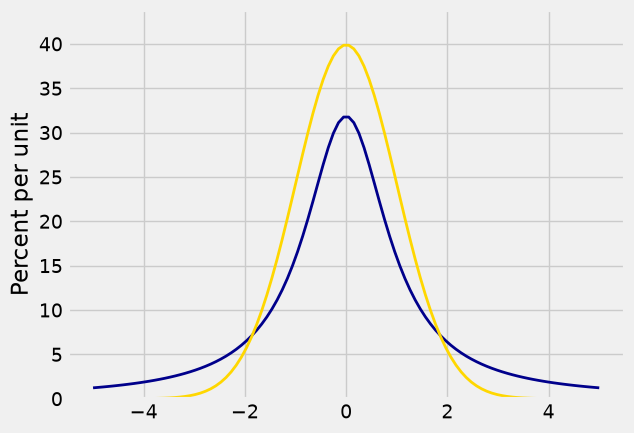

In [39]:
# Answer to b

# Plotting interval on the horizontal axis: -5 to 5
# The first plot should be the Cauchy.
# The gold plot should be the standard normal curve.

Plot_continuous([-5, 5], stats.cauchy.pdf)
Plot_continuous([-5, 5], stats.norm.pdf, color='gold')


**c)** For $Y$ with the Cauchy density, use calculus to show that $E(\lvert Y \rvert ) = \infty$. Thus $E(Y)$ is undefined even though the density of $Y$ is symmetric about 0.

The Cauchy curve is called the [Witch of Agnesi](https://en.wikipedia.org/wiki/Witch_of_Agnesi). Skim the History and Applications sections of the Wikipedia article.

**d)** Explain what is being plotted by the code below, and discuss what you see in the graph in relation to the Weak Law of Large Numbers. Run the cell **several times** before you answer. You should also vary $N$.

[`stats.cauchy.rvs(size = N)` returns an array of $N$ i.i.d. Cauchy random numbers.]

c)
$$
E(\mid Y \mid)
=
\int_{-\infty}^{\infty} \frac{\mid y \mid}{\pi (1+y^2)} \, dy
=
2 \int_{0}^{\infty} \frac{y}{\pi (1+y^2)} \, dy
=
\frac{1}{\pi} [log(1+y^2)]_{0}^{\infty}
\to \infty
$$

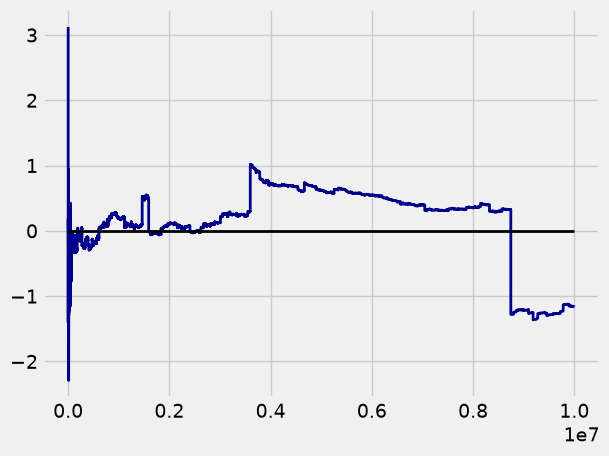

In [40]:
# Part d: run this several times
N = 10000000
n = np.arange(1, N+1)
x = stats.cauchy.rvs(size = N)
y = np.cumsum(x)/n
plt.plot(n, y, color='darkblue', lw=2)
plt.plot([0, N], [0, 0], color='k', lw=2);

d)
绘制的是从 1 - n 样本的均值的变化

弱大数定律: 大样本的均值以高概率接近总体均值

从 c 部分可以看出, E(Y) 不存在 (\infty)
样本均值很容易因为异常值而出现扰动, 从而不会接近某一个具体的值
波动不会随着 n 增大 而减小

\newpage

## 4. The Gamma Family ##
In this problem you will start with some calculus exercises and then develop one of the fundamental families of densities. An already-familiar distribution belongs to this family, as you will show in the next exercise (Problem 6). In the next exercise, you will also see that this family has been used to model individual infectiousness due to the novel coronavirus (COVID-19).

Assume that $r > 0$ and $\lambda > 0$ are constants.

**a)** The *Gamma function* of mathematics is defined by
$$
\Gamma (r) ~ = ~ \int_0^\infty t^{r-1} e^{-t} dt
$$

That letter is the upper case Greek letter Gamma. You can assume that the integral converges and that therefore $\Gamma(r)$ is a positive number.

Use integration by parts to show that 
$$
\Gamma(r+1) ~ = ~ r\Gamma(r), ~~~ r > 0
$$

**b)** Use part (a) and induction to show that if $r$ is a positive integer then $\Gamma(r) = (r-1)!$. Thus the Gamma function is a continuous extension of the factorial function.

**c)** Let $X$ have density given by
$$
f_X(t) =
\begin{cases}
\dfrac{1}{\Gamma(r)} t^{r-1}e^{-t}, ~~~ t > 0 \\
0 ~~~~~~~~~~~~~~~~~~~~ \text{otherwise}
\end{cases}
$$

Let $Y = \frac{1}{\lambda} X$. Show that the density of $Y$ is

$$
f_Y(t) =
\begin{cases}
\dfrac{\lambda^r}{\Gamma(r)} t^{r-1}e^{-\lambda t}, ~~~ t > 0 \\
0 ~~~~~~~~~~~~~~~~~~~~ \text{otherwise}
\end{cases}
$$

The density of $Y$ is called the gamma $(r, \lambda)$ density.

**d)** Use (c) and the [textbook](https://data140.org/textbook/content/chapter-16/two-to-one-functions/#square-of-the-standard-normal) to confirm that if $Z$ has the standard normal density then $Z^2$ has the gamma $(1/2, 1/2)$ density. Hence find $\Gamma (1/2)$, and then use (a) to find $\Gamma (3/2)$ and $\Gamma (5/2)$. Please don't leave any integrals in your answers.

**Shapes of Gamma Densities:** Part (c) shows that the gamma $(r, \lambda)$ density is obtained as a change of scale (units of measurement) starting with a gamma $(r, 1)$ random variable and multiplying it by $1/\lambda$. That is why `stats` calls $1/\lambda$ the *scale parameter* of the gamma density. The parameter $\lambda$ is called the *rate*.

The parameter $r$ determines the shape of the curve and is called the *shape parameter*. To see why, it helps to look at some plots.

The method `stats.gamma.pdf` can be used with the following arguments to return the value of the density:
- the value of $t$ (possibly an array) at which to evaluate the density
- $r$
- $\lambda$ specified as `scale=1/λ`

Run the cell below to see overlaid graphs of the several gamma densities with different values of $r$ but the same rate $\lambda$. You will see why $r$ is called the shape parameter.

a)
$$
\Gamma (r+1) 
= 
\int_0^\infty t^r e^{-t} dt 
= 
[-e^{-t}t^r]_{0}^{\infty} - \int_{0}^{\infty} -e^{-t} r t^{r-1} dt 
= 
\int_{0}^{\infty} e^{-t} r t^{r-1} dt 
= 
r \Gamma(r)
$$

b)
对于 r = 1
$$
\Gamma(r)
=
\int_{0}^{\infty} e^{-t} dt
=
1
$$

假设对于 r <= k, 有 $\Gamma(r) = (r-1)!$

对于 r = k + 1, 有 
$$
\Gamma(k+1) = k\Gamma(k)
=
k \times (k-1)!
=
k!
$$
因此 假设成立, 证毕

c)
$$
Y
=
g(x) 
= 
\frac{X}{\lambda}
$$

$$
g'(x)
=
\frac{1}{\lambda}
$$

$$ 
X = \lambda Y
$$

$$
f_Y(t) 
=
\lambda (\lambda t)^{r-1} e^{-\lambda t} \frac{1}{\Gamma(r)}
=
\lambda^r t^{r-1} e^{-\lambda t} \frac{1}{\Gamma(r)}
$$

d)
通过 textbook 中同样的[方法](https://data140.org/textbook/content/chapter-16/two-to-one-functions/#square-of-the-standard-normal), 可以验证满足 $Gamma(1/2, 1/2) $density

$$
\Gamma(\frac{1}{2})
=
\sqrt{\pi}
$$

$$
\Gamma(\frac{3}{2}) 
= 
\Gamma(1 + \frac{1}{2})
=
\frac{1}{2} \Gamma(\frac{1}{2})
= 
\frac{\sqrt{\pi}}{2}
$$

$$
\Gamma(\frac{5}{2}) = \frac{3\sqrt{\pi}}{4}
$$

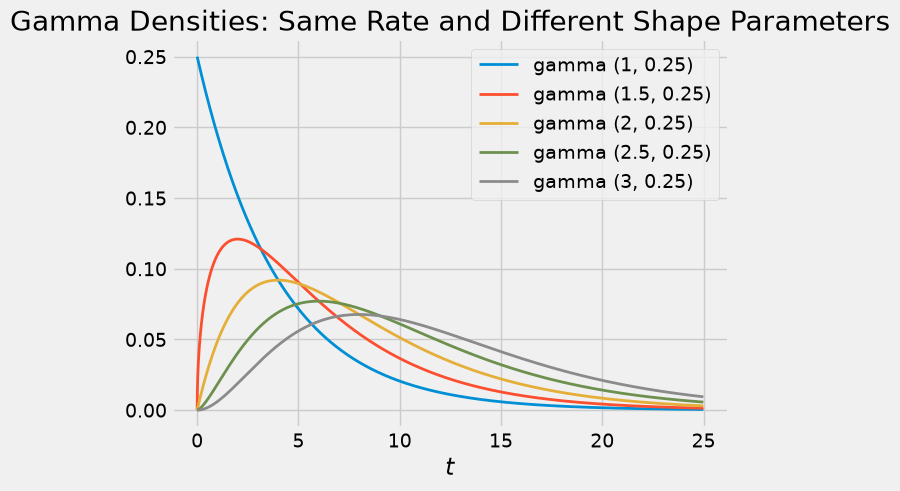

In [42]:
# Part d
t = np.arange(0, 25, 0.01)
r_1 = stats.gamma.pdf(t, 1, scale=1/0.25)
r_1_5 = stats.gamma.pdf(t, 1.5, scale=1/0.25)
r_2 = stats.gamma.pdf(t, 2, scale=1/0.25)
r_2_5 = stats.gamma.pdf(t, 2.5, scale=1/0.25)
r_3 = stats.gamma.pdf(t, 3, scale=1/0.25)
plt.plot(t, r_1, lw=2, label='gamma (1, 0.25)')
plt.plot(t, r_1_5, lw=2, label='gamma (1.5, 0.25)')
plt.plot(t, r_2, lw=2, label='gamma (2, 0.25)')
plt.plot(t, r_2_5, lw=2, label='gamma (2.5, 0.25)')
plt.plot(t, r_3, lw=2, label='gamma (3, 0.25)')
plt.xlabel('$t$')
plt.legend()
plt.title('Gamma Densities: Same Rate and Different Shape Parameters');

\newpage

## 5. Mean and Variance of the Gamma ##
As in Question 4, let $r$ and $\lambda$ be positive constants.

**a)** Use Question 4(c) and properties of densities to evaluate
$$
\int_0^\infty t^{r-1}e^{-\lambda t} dt
$$
in terms of $r$, $\lambda$, and the Gamma function. For what follows, keep in mind that your formula is correct for all positive $r$.

**b)** Let $T$ have gamma $(r, \lambda)$ density. Use (a) and 5(a) to find a simple formula for $E(T)$ in terms of $r$ and $\lambda$. Please don't leave any integrals or Gamma functions in your answer.

**c)** For $T$ as in (b), find $E(T^2)$ in terms of the Gamma function. 

**d)** Find $Var(T)$. **Make sure to simplify all integrals and gamma functions. As usual, show your work.** 

**e)** Identify the gamma $(1, \lambda)$ density as one that has another famous name, and confirm that your answers to (b) and (c) are consistent with what you already know about that density.

**f) [CODE]** A [report](https://www.imperial.ac.uk/media/imperial-college/medicine/sph/ide/gida-fellowships/Imperial-College-COVID19-NPI-modelling-16-03-2020.pdf) from Imperial College, UK, is believed to have spurred the US government to take steps to slow down the spread of Covid in March 2020. The assumptions of one of the main models is in the penultimate paragraph on Page 4. Note the sentence, "Individual infectiousness is assumed to be variable, described by a gamma distribution with mean 1 and shape parameter $\alpha = 0.25$." 

Broadly speaking, infectiousness is quantified by the number of cases directly generated by one infected person. We denote this quantity as the random variable $R$. The model produced by researchers at Imperial College estimates the distribution of $R$ under COVID-19, based on prior knowledge of similar viruses and respiratory diseases.

Plot the gamma distribution used in the model. The horizontal axis should start at 0 and extend to 2 standard deviations above the mean of 1. Make sure to label your x-axis.

We are not giving you any skeleton code for this. Use what you've learned from the code cells above, and please give your plot an appropriate title.

a)
$$
\int_0^\infty t^{r-1}e^{-\lambda t} dt
=
\int_0^\infty \frac{\Gamma(r)}{\lambda^r} Gamma(r, \lambda) dt
=
\frac{\Gamma(r)}{\lambda^r}
$$

b)

$$
E(T) 
= 
\frac{\lambda^r}{\Gamma(r)} \int_{0}^{\infty} t^r e^{-\lambda t} dt 
= 
\frac{\lambda^r}{\Gamma(r)} \cdot \frac{\Gamma(r+1)}{\lambda^{r+1}} 
= 
\frac{r}{\lambda}$$

c)
$$
E(T^2)
=
\int_{0}^{\infty} \frac{\lambda^r}{\Gamma(r)} t^{r-1} e^{-\lambda t} t^2 dt
=
\frac{\lambda^r}{\Gamma(r)} \int_{0}^{\infty} t^{r+1} e^{-\lambda t} dt
=
\frac{\lambda^r}{\Gamma(r)} \frac{\Gamma(r+2)}{\lambda^{r+2}}
=
\frac{(r+1)r}{\lambda^2}
$$

d)
$$
Var(T) 
=
E(T^2) - E(T)^2
=
\frac{r}{\lambda^2}
$$

e)
$$
Gamma(1, \lambda) 
=
\lambda e^{-\lambda t}
$$
指数分布

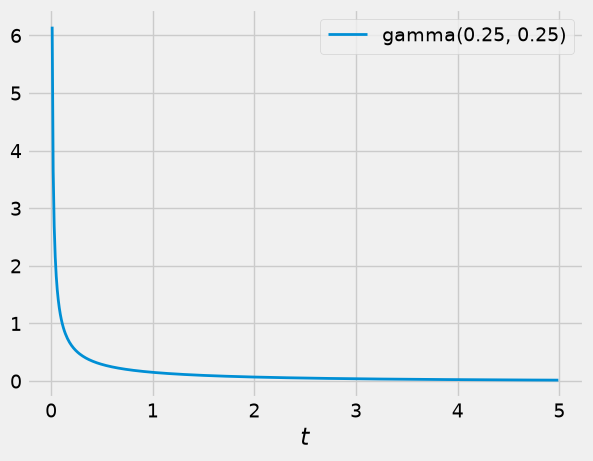

In [45]:
# Answer to f
t = np.arange(0, 5, 0.01)
r_1 = stats.gamma.pdf(t, 0.25, scale=1/0.25)
plt.plot(t, r_1, lw=2, label='gamma(0.25, 0.25)')
plt.xlabel('$t$')
plt.legend()

\newpage

## Submission Instructions ##

Many assignments throughout the course will have a written portion and a code portion. Please follow the directions below to properly submit both portions.

### Written Portion ###
*  Scan all the pages into a PDF. You can use any scanner or a phone using applications such as CamScanner. Please **DO NOT** simply take pictures using your phone. 
* Please start a new page for each question. If you have already written multiple questions on the same page, you can crop the image in CamScanner or fold your page over (the old-fashioned way). This helps expedite grading.
* It is your responsibility to check that all the work on all the scanned pages is legible.
* If you used $\LaTeX$ to do the written portions, you do not need to do any scanning; you can just download the whole notebook as a PDF via LaTeX.

### Code Portion ###
* Save your notebook using `File > Save and Checkpoint`.
* Generate a PDF file using `File > Download As > PDF via LaTeX`. This might take a few seconds and will automatically download a PDF version of this notebook.
    * If you have issues, please post a follow-up on the general Homework 8 Ed thread.
    
### Submitting ###
* Combine the PDFs from the written and code portions into one PDF. [Here](https://smallpdf.com/merge-pdf) is a useful tool for doing so. 
* Submit the assignment to Homework 8 on Gradescope. 
* **Make sure to assign each page of your pdf to the correct question.**
* **It is your responsibility to verify that all of your work shows up in your final PDF submission.**

If you are having difficulties scanning, uploading, or submitting your work, please read the [Ed Thread](https://edstem.org/us/courses/94054/discussion/7533569) on this topic and post a follow-up on the general Homework 8 Ed thread.


## **We will not grade assignments which do not have pages selected for each question.** ##